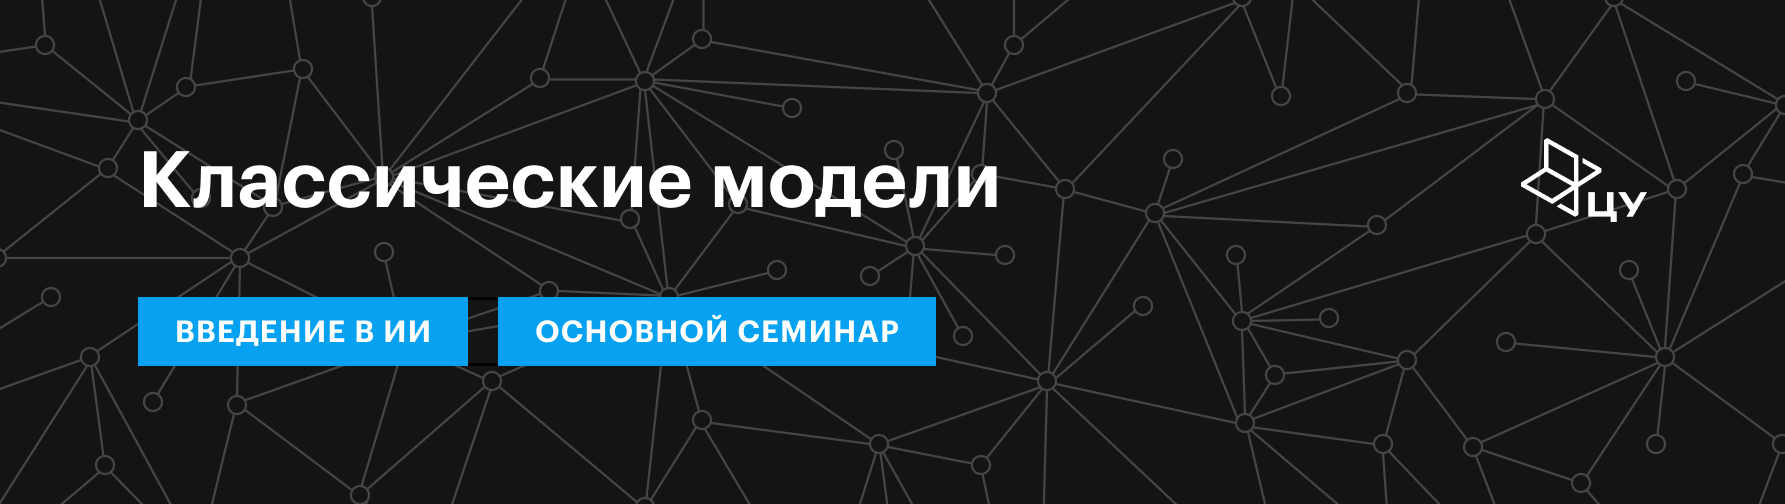

#  Алгоритмы ML

На этом семинаре мы рассмотрим несколько алгоритмов машинного обучения и обсудим особенности их применения и интерпретации.

Из этого семинара ты узнаешь:
- как применять логистическую регрессию и интерпретировать её результаты;
- как экспериментировать с деревом решений, случайным лесом и бустингом;
- почему «большой коэффициент» в линейной регрессии не всегда означает «важный признак»;
- как работает стандартизация, зачем нужен правильный пайплайн и как оценивать важность через перемешивание признака;
- как интерпретировать модель при помощи решающего дерева.


## Подготовка

На этом семинаре будет много экспериментов. Чтобы было удобно:
- будем фиксировать `random_state`;
- будем рисовать **разделяющую кривую** для двумерных задач.


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_moons, make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.metrics import accuracy_score, r2_score, precision_score, recall_score





### Вспомогательная функция для графика разделяющей поверхности

Она будет работать для моделей, у которых есть метод `.predict()` и которые обучены на данных размерности 2.


In [ ]:
# @title Вспомогательная графика
def plot_dots(X, y, mesh_res=0.02, alpha=0.35, title=None):
    """Рисует разделяющую поверхность для 2D-классификации."""
    X = np.asarray(X)
    y = np.asarray(y)

    x1_min, x1_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    x2_min, x2_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, mesh_res),
        np.arange(x2_min, x2_max, mesh_res),
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]

    cmap_bg = ListedColormap(("tab:red", "tab:blue"))
    cmap_pts = ListedColormap(("darkred", "darkblue"))

    plt.figure(figsize=(8, 5))

    # Точки
    for cls in np.unique(y):
        plt.scatter(
            X[y == cls, 0], X[y == cls, 1],
            s=25, alpha=0.9, label=f"class {cls}",
            c=[cmap_pts(int(cls))]
        )

    plt.xlabel("x1")
    plt.ylabel("x2")
    if title:
        plt.title(title)
    plt.legend()
    plt.show()



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_surface(X, y, model, threshold=0.5, mesh_res=0.005,
                          alpha=0.35, title=None, draw_dots=True):
    """Рисует разделяющую поверхность для 2D-классификации с явным порогом."""
    X = np.asarray(X)
    y = np.asarray(y)

    x1_min, x1_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    x2_min, x2_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, mesh_res),
        np.arange(x2_min, x2_max, mesh_res),
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]

    # Вероятность класса 1 -> порог -> класс
    proba = model.predict_proba(grid)[:, 1]
    Z = (proba >= threshold).astype(int).reshape(xx1.shape)

    cmap_bg = ListedColormap(("tab:red", "tab:blue"))
    cmap_pts = ListedColormap(("darkred", "darkblue"))

    plt.figure(figsize=(10, 6))
    plt.contourf(xx1, xx2, Z, alpha=alpha, cmap=cmap_bg)

    if draw_dots:
        for cls in np.unique(y):
            plt.scatter(
                X[y == cls, 0], X[y == cls, 1],
                s=25, alpha=0.9, label=f"class {cls}",
                c=[cmap_pts(int(cls))]
            )

    plt.xticks([])
    plt.yticks([])

    # plt.xlabel("x1")
    # plt.ylabel("x2")
    # plt.title(title or f"Decision surface (threshold={threshold:.2f})")
    # plt.legend()
    plt.show()



## Логистическая регрессия


Сгенерируем классический датасет «Две луны».

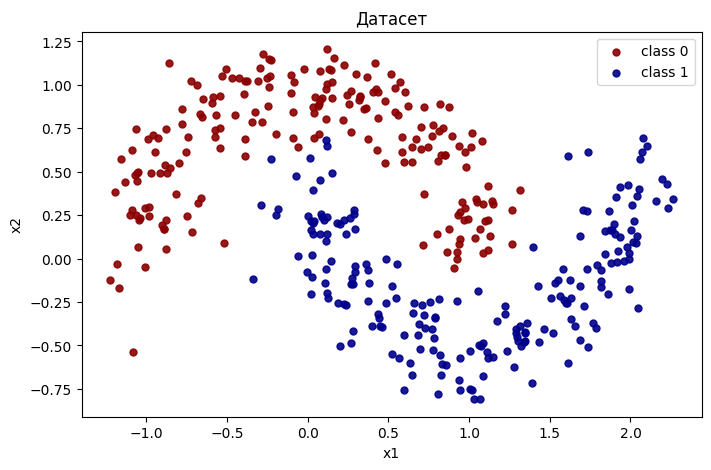

In [ ]:
X_m, y_m = make_moons(n_samples=1000, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_m, y_m, test_size=0.25, random_state=42, stratify=y_m)
plot_dots(X_m, y_m, title="Датасет")

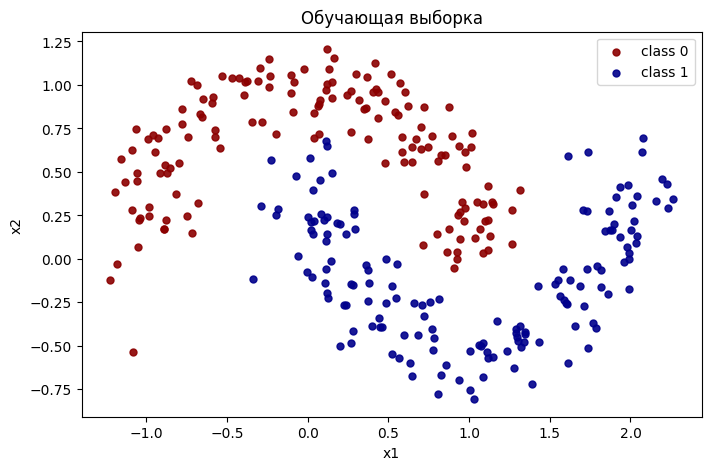

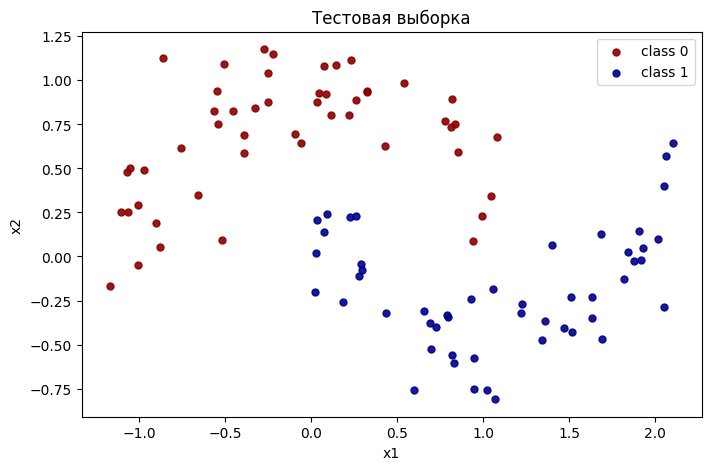

In [ ]:
plot_dots(X_train, y_train, title="Обучающая выборка")
plot_dots(X_test, y_test, title="Тестовая выборка")

### Задание 1

- Обучи на лунах модель `LogisticRegression`.

- Выведи train/test accuracy, precision, recall.

Для более наглядных визуализаций используй $X_m$ и $y_m$.


In [ ]:
logreg_model = # Напиши код здесь

# Fit

# Prerict

# Метрики

plot_decision_surface(X_m, y_m, logreg_model, title="LogReg")

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

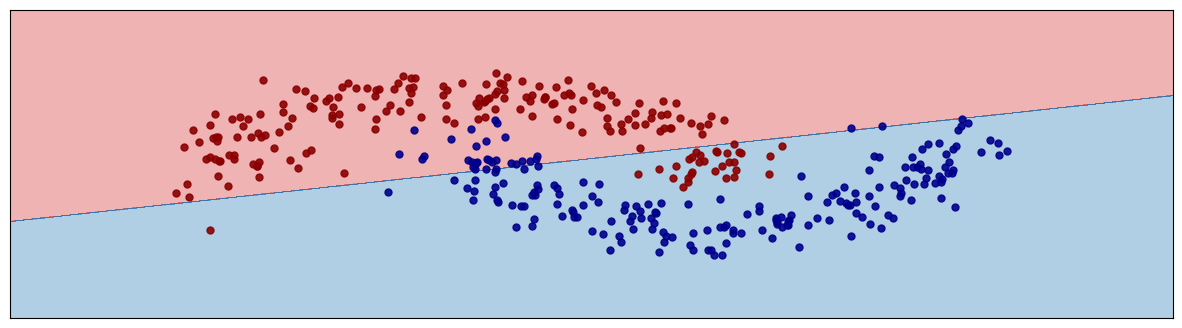

          LogReg | acc=0.843 | precision=0.841 | recall=0.845


In [ ]:
model = LogisticRegression(max_iter=500, n_jobs=-1)

model.fit(X_m, y_m)

te_acc = accuracy_score(y_m, model.predict(X_m))
plot_decision_surface(X_m, y_m, model, title="LogReg")
prec = precision_score(y_m, model.predict(X_m), zero_division=0)
rec  = recall_score(y_m, model.predict(X_m), zero_division=0)

print(f"{'LogReg':>16} | acc={te_acc:.3f} | precision={prec:.3f} | recall={rec:.3f}")

## Порог логистической регрессии

Логистическая регрессия считает **вероятность** положительного класса:

$$p(y=1\mid x) = \sigma((w;x) + b), \quad \sigma(z)=\frac{1}{1+e^{-z}}.$$

Чтобы получить класс $\{0,1\}$, мы выбираем порог $t$ и задаём условия:

- если $p ≥ t$, предсказываем класс 1;
- если $p < t$, предсказываем класс 0.

По умолчанию в `model.predict` используется $t=0,5$.

Если **уменьшать** $t$, модель будет чаще выдавать 1:
- recall обычно растёт (меньше пропусков положительных объектов);
- precision обычно падает (больше ложных срабатываний).

Если **увеличивать** $t$, всё будет происходить наоборот.


### Задание 2

Создай функцию, предсказывающую метку класса с учётом порога.


In [ ]:
def predict_with_threshold(model, X, threshold=0.5):

    return # 0 или 1

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
def predict_with_threshold(model, X, threshold=0.5):
    """Классы по вероятностям с заданным порогом."""
    p = model.predict_proba(X)[:, 1]
    return (p >= threshold).astype(int)

### Задание 3

Теперь посмотри, как разные пороги влияют на вид разделяющей прямой.

Необходимо найти пороги, при которых будет максимальным:


- precision,

- recall.


In [ ]:
tr = 0.04

model = LogisticRegression(max_iter=2000, n_jobs=-1)

model.fit(X_m, y_m)


te_acc = accuracy_score(y_m, predict_with_threshold(model, X_m, tr))
prec = precision_score(y_m, predict_with_threshold(model, X_m, tr), zero_division=0)
rec  = recall_score(y_m, predict_with_threshold(model, X_m, tr), zero_division=0)

print(f"{'LogReg':>16} || acc={te_acc:.3f} | precision={prec:.3f} | recall={rec:.3f}")
plot_decision_surface(X_m, y_m, model, tr, title="LogReg")

NameError: name 'predict_with_threshold' is not defined

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Максимум точности: порог = `0.98`

Максимум полноты: порог = `0.04`

### Задание 4

Какая модель лучше: где больше precision или где больше recall?


#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Ответ зависит от задачи.

Если очень важно ничего не упустить - например, поймать всех преступников до их проникновения в самолет, то нас интересует максимизация recall.

Еще один пример - задача диагностирования рака: в ней мы тоже сталкиваемся с максимизацией recall.

Если же рассматривать задачу рекомендации фильмов, то в ней зачастую наиболее важный параметр - precision, потому что нужно как можно быстрее заинтересовать зрителя и удержать его внимание.

## Дерево решений на лунах

Как мы уже говорили, дерево решений последовательно разбивает пространство признаков, используя условия вида:


> если $x_j ≤ t$, то налево, иначе — направо.

Из этого получается «ступенчатая» граница, и дерево легко делает нелинейные разделения.

На лекции мы разобрали основной алгоритм построения решающего дерева, теперь попробуем найти знакомые концепции и понять, за что отвечают ранее не известные нам гиперпараметры.

Ключевые гиперпараметры:
- `max_depth` — максимальная глубина;

- `min_samples_split` — минимум объектов в узле, чтобы пытаться его разделить;

- `min_samples_leaf` — минимум объектов в листе;

- `criterion` — метрика «качества» разбиения (`gini`, `entropy`). Энтропия обычно лучше работает с несбалансированными данными, но `gini` легче считать, поэтому она будет работать быстрее.


### Задание 5

Обучи несколько деревьев и посмотри, как гиперпараметры меняют границу.

1) `DecisionTreeClassifier(random_state=42)` — без ограничений.
2) Дерево с `max_depth=2`.
3) Дерево с `min_samples_leaf=20`.

Для каждой модели:
- выведи `train/test accuracy`;
- нарисуй разделяющую поверхность.

Не бойся экспериментировать.


#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

 train acc=0.877 | test acc=0.950


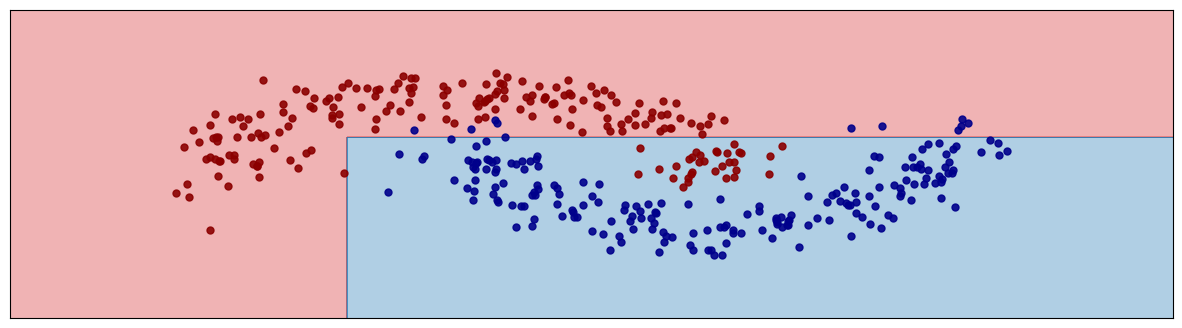

In [ ]:
model = DecisionTreeClassifier(random_state=42, max_depth=2, min_samples_leaf=20)
model.fit(X_train, y_train)

tr_acc = accuracy_score(y_train, model.predict(X_train))
te_acc = accuracy_score(y_test, model.predict(X_test))
print(f" train acc={tr_acc:.3f} | test acc={te_acc:.3f}")
plot_decision_surface(X_m, y_m, model, title=f"Tree")


## Случайный лес и бустинг

> **Случайный лес** — это множество деревьев, обученных на бутстрап-выборках и с рандомизацией признаков.

При использовании такого подхода:
- граница становится стабильнее;
- переобучение меньше, чем у одиночного дерева;
- модель почти не требует тонкой настройки, но может быть «тяжёлой».

> **Бустинг над деревьями** (например, Gradient Boosting / XGBoost / CatBoost / LightGBM) строит деревья последовательно:
каждое следующее исправляет ошибки предыдущих.

Это один из самых сильных подходов для табличных данных.


### Задание 6

Сравни на лунах:

1) `RandomForestClassifier`.
2) `GradientBoostingClassifier`.

Для каждой модели:
- выведи `train/test accuracy`;
- нарисуй разделяющую поверхность.



In [ ]:
# Напиши код здесь

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

    RandomForest | train acc=1.000 | test acc=0.990


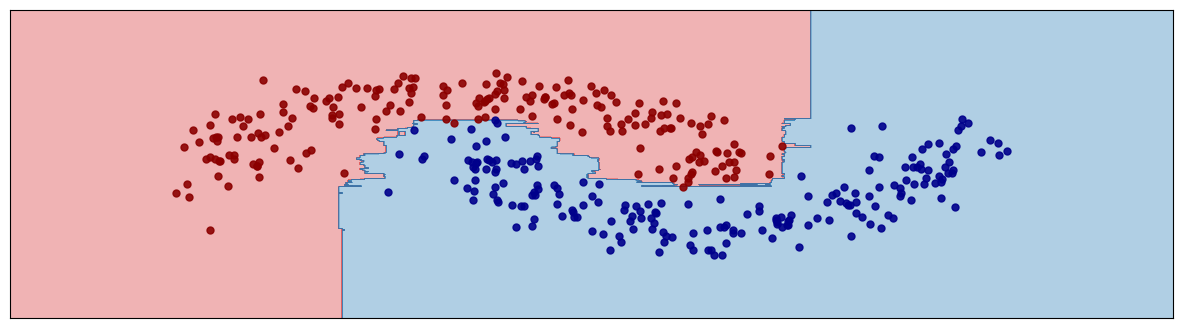

GradientBoosting | train acc=1.000 | test acc=0.990


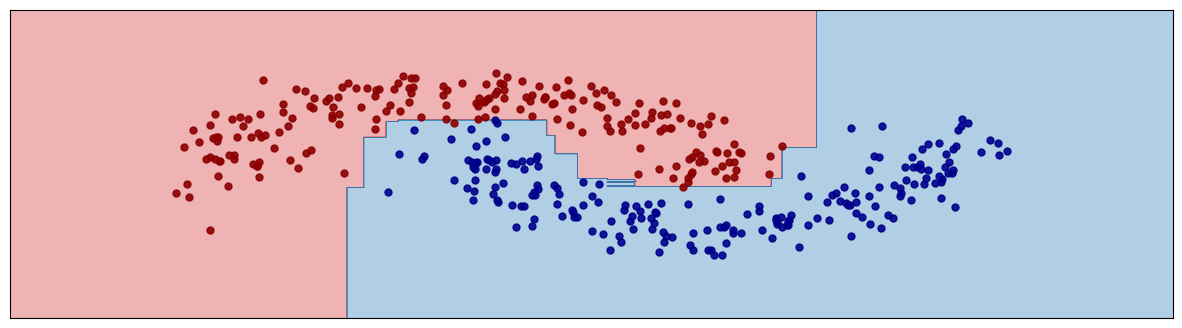

In [ ]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

for name, clf in models.items():
    clf.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"{name:>16} | train acc={tr_acc:.3f} | test acc={te_acc:.3f}")
    plot_decision_surface(X_m, y_m, clf, title=name)


## Важность признаков и масштабирование

До этого мы работали в основном с двумерными признаками и оценивали границу визуально.

В реальных задачах ситуация сложнее:
- признаков много;
- нельзя визуализировать границу;
- нужно понимать, какие признаки приоритетнее и почему модель так решила.

На последний пункт стоит обратить особое внимание: в некоторых вопросах интерпретируемость бывает важнее обычных метрик, например, при выдаче кредита.

Нельзя просто обучить нейросеть и использовать её для принятия кредитных решений. Если модель откажет клиенту и мы не сможем объяснить причину, это может привести к проблемам. Клиент вправе потребовать обоснования решения.

Начнём разбираться с важностью признаков (англ. feature importance) на примере линейной регрессии.



## Перемешивание признака как оценка важности

Алгоритм.

1) Обучаем модель (любую), измеряем качество на test.
2) Берём признак, который хотим протестировать на важность, **случайно перемешиваем** его значения в test.
3) Снова измеряем качество.
4) Насколько сильно упало качество — настолько признак был важен для этой модели и этого датасета.

Важно:
- перемешиваем только test;
- делаем это для каждого признака по отдельности.


#### Пример реализации feature importance

In [ ]:
from sklearn.pipeline import Pipeline # Для красивой сборки решения

Baseline R2: 0.4849058889476755


,feature,r2_drop
0,s1,0.560070
1,s5,0.496013
2,s2,0.332433
3,bmi,0.153037
4,sex,0.075912
5,s4,0.041241
6,s3,0.038109
7,bp,0.014047
8,s6,0.003367
9,age,-0.005699


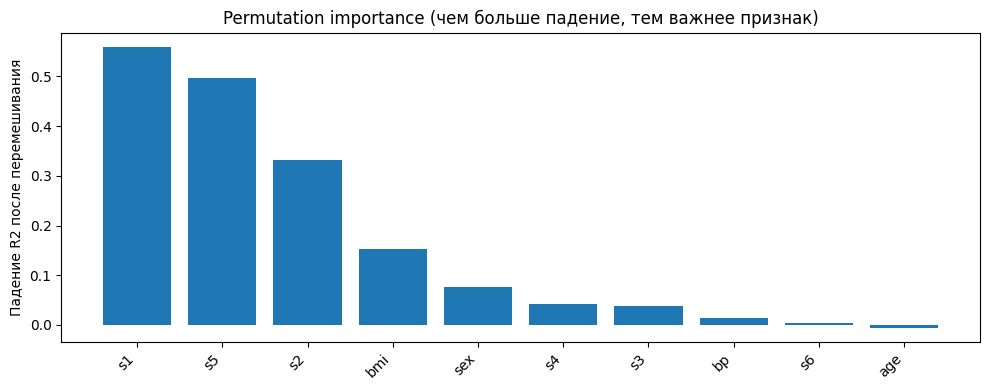

In [ ]:
from sklearn.datasets import load_diabetes

# 1) Загружаем готовый регрессионный датасет
diab = load_diabetes(as_frame=True)
X_reg = diab.data
y_reg = diab.target

# 2) Train/test split
Xtr_train, Xtr_test, ytr_train, ytr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

# 3) Pipeline: StandardScaler -> LinearRegression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])
pipe.fit(Xtr_train, ytr_train)

base_r2 = r2_score(ytr_test, pipe.predict(Xtr_test))
print("Baseline R2:", base_r2)

# 4) Permutation importance вручную
rng = np.random.default_rng(42)
drops = []

for col in X_reg.columns:
    X_perm = Xtr_test.copy()
    X_perm[col] = rng.permutation(X_perm[col].to_numpy())
    r2_perm = r2_score(ytr_test, pipe.predict(X_perm))
    drops.append((col, base_r2 - r2_perm))

imp_df = (
    pd.DataFrame(drops, columns=["feature", "r2_drop"])
      .sort_values("r2_drop", ascending=False)
      .reset_index(drop=True)
)

display(imp_df)

# 5) Barplot
plt.figure(figsize=(10, 4))
plt.bar(imp_df["feature"], imp_df["r2_drop"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Падение R2 после перемешивания")
plt.title("Permutation importance (чем больше падение, тем важнее признак)")
plt.tight_layout()
plt.show()



## Интерпретация коэффициентов линейной регрессии

На лекции мы обсуждали, что если признаки сопоставимы по масштабу и между ними нет мультиколлинеарности (линейных зависимостей), то:

- знак $w_j$ показывает направление влияния;
- модуль $|w_j|$ часто воспринимают как коэффициент важности.

Но интерпретировать коэффициенты нужно с осторожностью.


### Задание 7

Почему при оценке важности признаков нужно учитывать их масштаб и наличие линейных зависимостей?


#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

1) Если признаки несопоставимы по масштабу (например, площадь квартиры в квадратных сантиметрах и удаленность от метро в минутах ходьбы), коэффициент одного признака будет очень маленьким, даже если он сильно влияет на цену.

2) Если признаки линейно зависимы, важность "размазывается" между ними, и коэффициенты уже не показывают реальный вклад каждого признака.

## Работа с разными масштабами

Мы уже разбирали, как выявлять мультиколлинеарные признаки, но с разными масштабами ещё не сталкивались.

Есть множество способов решить эту проблему, рассмотрим два наиболее популярных.

### Стандартизация признаков

**Стандартизация** переводит каждый признак в шкалу «среднее 0, стандартное отклонение 1»:

$x' = \frac{x - \mu}{\sigma}$,


- где $\mu$ — среднее по признаку (на train);
- $\sigma$ — стандартное отклонение по признаку (на train).

После стандартизации коэффициенты линейной модели становятся сопоставимыми: они показывают эффект **изменения на 1 стандартное отклонение**.


### MinMax scaling

**MinMax-масштабирование** переводит признак в заданный диапазон, чаще всего $[0, 1]$.

$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$.

Здесь $min$ и $max$ берутся по обучающей выборке, чтобы модель не узнала ответы раньше времени.

> **Важно.** Перед применением этого метода масштабирования необходимо убедиться в отсутствии выбросов, иначе основной массив данных сожмётся в очень узкий диапазон.

Чувствительными к масштабу являются:
- метрические модели (KNN),
- модели с регуляризацией (SVM),
- нейросети.


### Задание 8



Почему важно обучать стандартизатор только на train-выборке, а не на всём датасете?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Делая разделение на train и test, мы имитируем поступление новых данных, которых модель еще не видела. Если обучить стандартизатор на всем датасете, он "узнает" информацию о тестовых объектах раньше времени. Это может исказить оценку модели.

## Правильный пайплайн масштабирования данных

Подведём итог по масштабированию признаков.

Самая частая ошибка.

1) Отмасштабировать весь датасет.
2) Сделать train/test split.
3) Оценить качество.

Так делать нельзя, потому что статистики масштабирования $\mu$, $\sigma$, $min/max$ получаются нечестными.

Правильный алгоритм.

1) Разделить данные на train/test.
2) Обучить fit-масштабирование только на train.
3) Применить transform train и test одним и тем же масштабированием.
4) Обучить модель на train и оценить на test.


## Важность признаков в деревьях решений

У деревьев есть встроенный способ оценки важности признаков — `feature_importances_`.

Эта величина показывает, какие признаки модель использует при принятии решений.

Интуиция:
- дерево выбирает разбиения, которые сильнее всего уменьшают «зашумлённость» (`impurity`);
- если признак много раз участвует в таких разбиениях, он считается более важным.

На лекции мы говорили о том, что деревья решений можно визуализировать. Сделаем это и обсудим, что происходит на визуализациях и как работают деревья. Это важно, потому что дерево решений используется как базовый алгоритм в бустинге.

Рассматривать визуализации мы будем на классическом датасете машинного обучения — Breast Cancer. Его задача — предсказать по данным пациентки, есть ли у неё рак груди.

Загрузим датасет и рассмотрим его.

In [ ]:
# Загрузим датасет
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X_bc = data.data
y_bc = data.target

In [ ]:
X_bc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Перед тем как приступить к решению задачи, правильным было бы провести полноценное EDA и разобраться, что значат переменные. Но сегодня у нас другая цель, поэтому ограничимся визуализацией работы дерева решений.

In [ ]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)

tree = DecisionTreeClassifier(random_state=42,max_depth=3,min_samples_leaf=20)
tree.fit(Xb_train, yb_train)

acc = accuracy_score(yb_test, tree.predict(Xb_test))
print("Test accuracy:", acc)

Test accuracy: 0.916083916083916


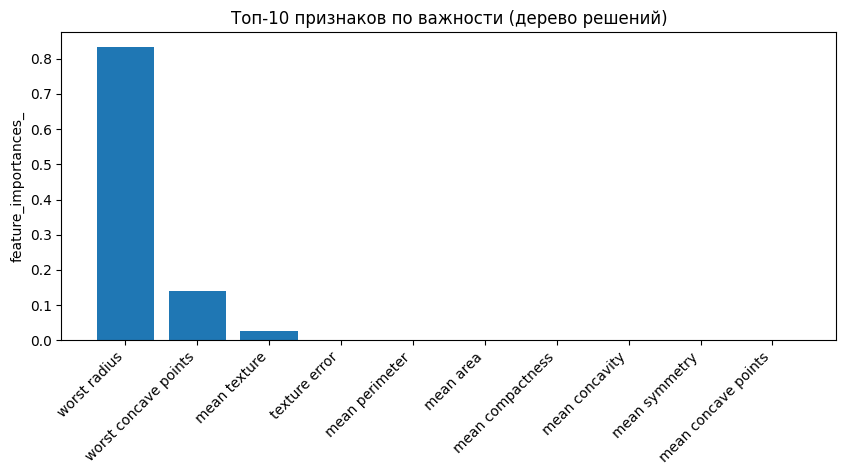

In [ ]:
imp = pd.Series(tree.feature_importances_, index=X_bc.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(imp.head(10).index, imp.head(10).values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("feature_importances_")
plt.title("Топ-10 признаков по важности (дерево решений)")
plt.show()

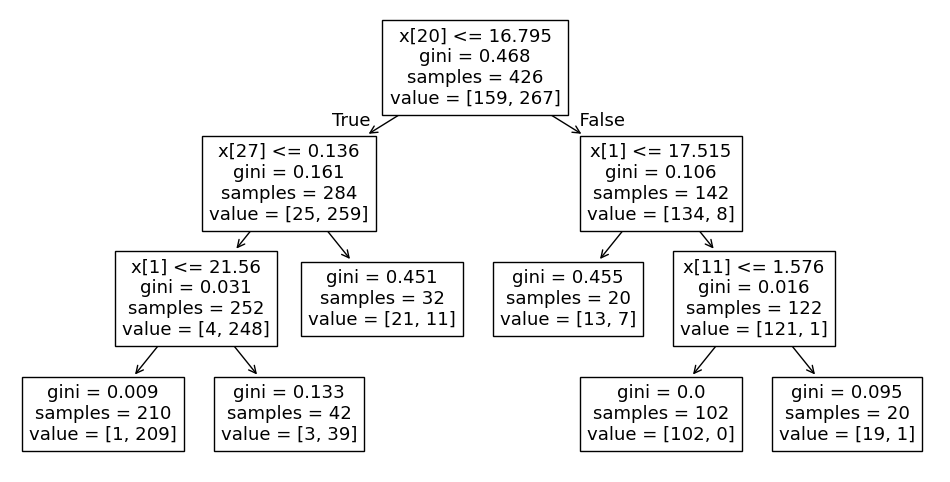

In [ ]:
# Простая визуализация дерева решений
plt.figure(figsize=(12, 6))
plot_tree(tree)
plt.show()


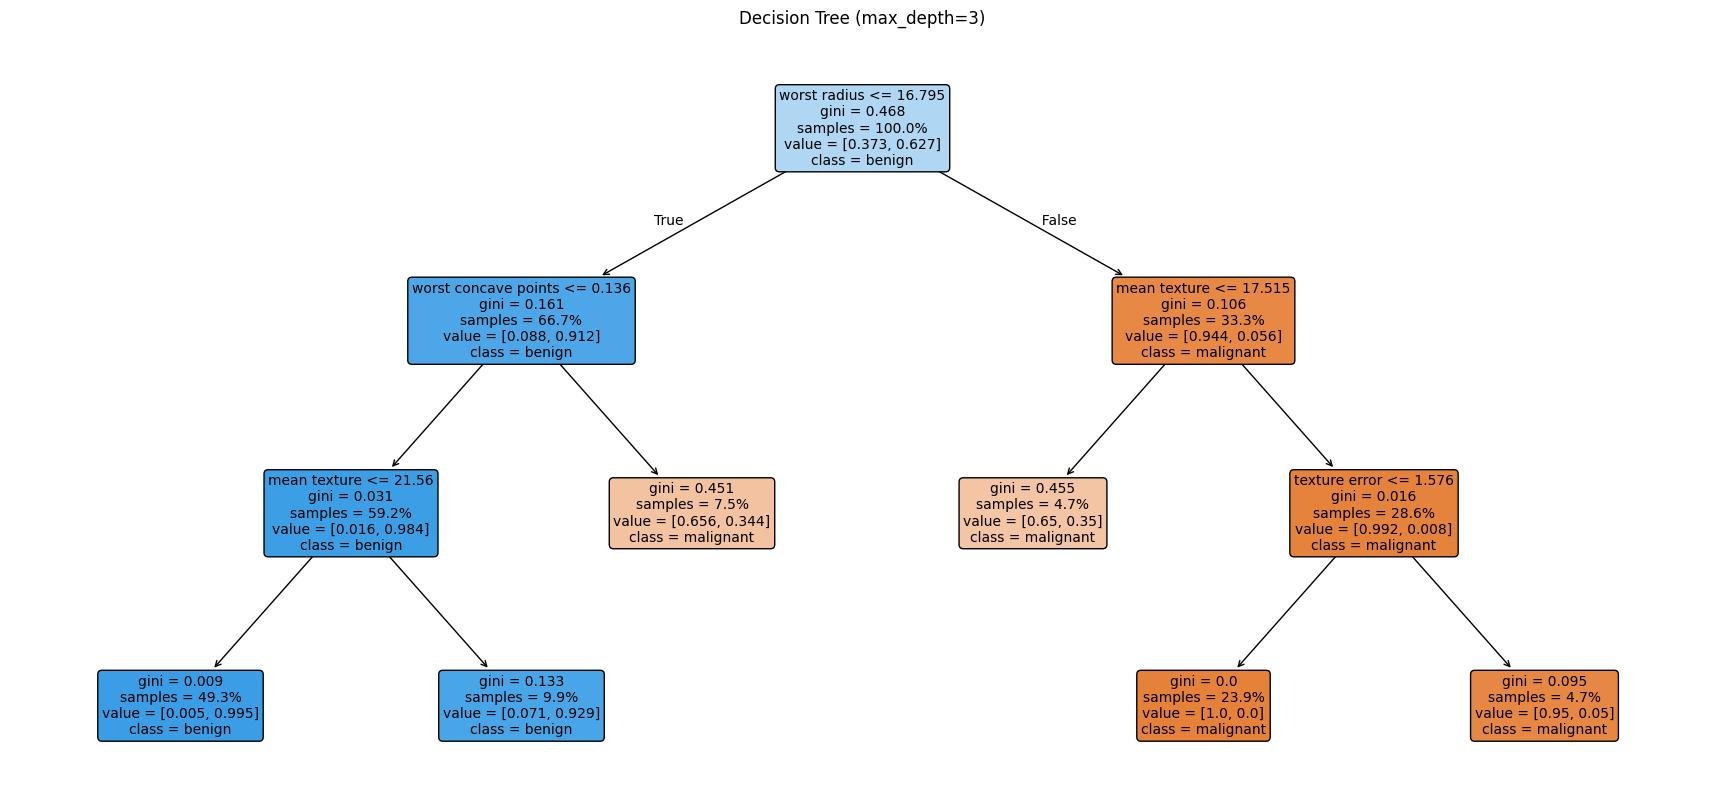

In [ ]:
# Более красивая и читабельная визуализация
plt.figure(figsize=(22, 10))
plot_tree(
    tree,
    feature_names=X_bc.columns,
    class_names=list(data.target_names),
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=3)")
plt.show()

### Задание 9



Как интерпретировать полученное дерево? Что означает текст в прямоугольниках?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

1. В верхнем листе дерева находится номер переменной и вопрос к ней. Вопрос задаётся для каждого наблюдения. Переменная `20` (`worst radius`) меньше `16,795`.
2. Чтобы выбрать переменную и вычислить значение для расщепления, мы перебирали для каждой переменной и всех возможных расщеплений значение `Impurity` и в итоге выбрали разбиение, где оно максимально. `Impurity` показывает, насколько разнообразные данные содержатся в листе: чем больше разнообразие, тем выше это значение. Нам это не нужно, мы хотим разделить датасет, чтобы в конечных листьях оказались объекты только одного класса.
3. `gini` — название критерия расщепления, с помощью которого считалось `Impurity`. Его значение для листа также указано.
4. `samples` — количество наблюдений в листе. После разбиения количество наблюдений в левом и правом листе в сумме равно количеству наблюдений в родительском листе.
5. `value` — количество наблюдений каждого класса в листе.

Сначала дерево спрашивает: радиус меньше `17`? Если да, то почти наверняка опухоль доброкачественная, если нет, скорее всего, злокачественная.

Дальше по аналогичному принципу строится каждое поддерево.